In [25]:
! pip install pandas
import pandas as pd

# Load the dataset
df = pd.read_csv("mushrooms.csv")


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [26]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [27]:
df.shape

(8124, 23)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [29]:
df["class"]

0       p
1       e
2       e
3       p
4       e
       ..
8119    e
8120    e
8121    e
8122    p
8123    e
Name: class, Length: 8124, dtype: object

In [30]:
# Features (X) and target (y)
X = df.drop(columns=["class"])
y = df["class"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFirst 3 rows of X:")
print(X.head(3))
print("\nFirst 3 labels of y:")
print(y.head(3))

X shape: (8124, 22)
y shape: (8124,)

First 3 rows of X:
  cap-shape cap-surface cap-color bruises odor gill-attachment gill-spacing  \
0         x           s         n       t    p               f            c   
1         x           s         y       t    a               f            c   
2         b           s         w       t    l               f            c   

  gill-size gill-color stalk-shape  ... stalk-surface-below-ring  \
0         n          k           e  ...                        s   
1         b          k           e  ...                        s   
2         b          n           e  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w   
1                      w                      w         p          w   
2                      w                      w         p          w   

  ring-number ring-type spore-print-color population habitat  
0

In [31]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Create one-hot encoder for all columns (all are categorical)
ohe = OneHotEncoder(drop="first", sparse_output=False)  # sparse=False: get NumPy array

# Apply one-hot to all columns of X
X_encoded = ohe.fit_transform(X)

# Also encode the target (p → 0, e → 1)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(X_encoded[:3])


[[0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1.
  0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0.
  0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0.
  0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0.
  0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0.
  0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0.
  0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0.
  0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0.
  0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0.
  0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0.]]


In [32]:
print(y_encoded[:3])

[1 0 0]


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # keep same % of p/e in both sets
)

# 1. Default Decision Tree (criterion='gini')
dt_gini = DecisionTreeClassifier(random_state=42)
dt_gini.fit(X_train, y_train)

# Predict on test set
y_pred_gini = dt_gini.predict(X_test)

# Check accuracy
acc_gini = accuracy_score(y_test, y_pred_gini)
print("Gini Tree Test Accuracy:", acc_gini)
print("\nClassification Report (Gini):")
print(classification_report(y_test, y_pred_gini, target_names=["poisonous (p)", "edible (e)"]))

Gini Tree Test Accuracy: 1.0

Classification Report (Gini):
               precision    recall  f1-score   support

poisonous (p)       1.00      1.00      1.00       842
   edible (e)       1.00      1.00      1.00       783

     accuracy                           1.00      1625
    macro avg       1.00      1.00      1.00      1625
 weighted avg       1.00      1.00      1.00      1625



In [34]:
# 2. Entropy-based tree
dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)
dt_entropy.fit(X_train, y_train)

y_pred_entropy = dt_entropy.predict(X_test)
acc_entropy = accuracy_score(y_test, y_pred_entropy)

print("Entropy Tree Test Accuracy:", acc_entropy)

# Side‑by‑side comparison
print("\nAccuracy comparison:")
print("Gini     :", acc_gini)
print("Entropy  :", acc_entropy)

Entropy Tree Test Accuracy: 1.0

Accuracy comparison:
Gini     : 1.0
Entropy  : 1.0


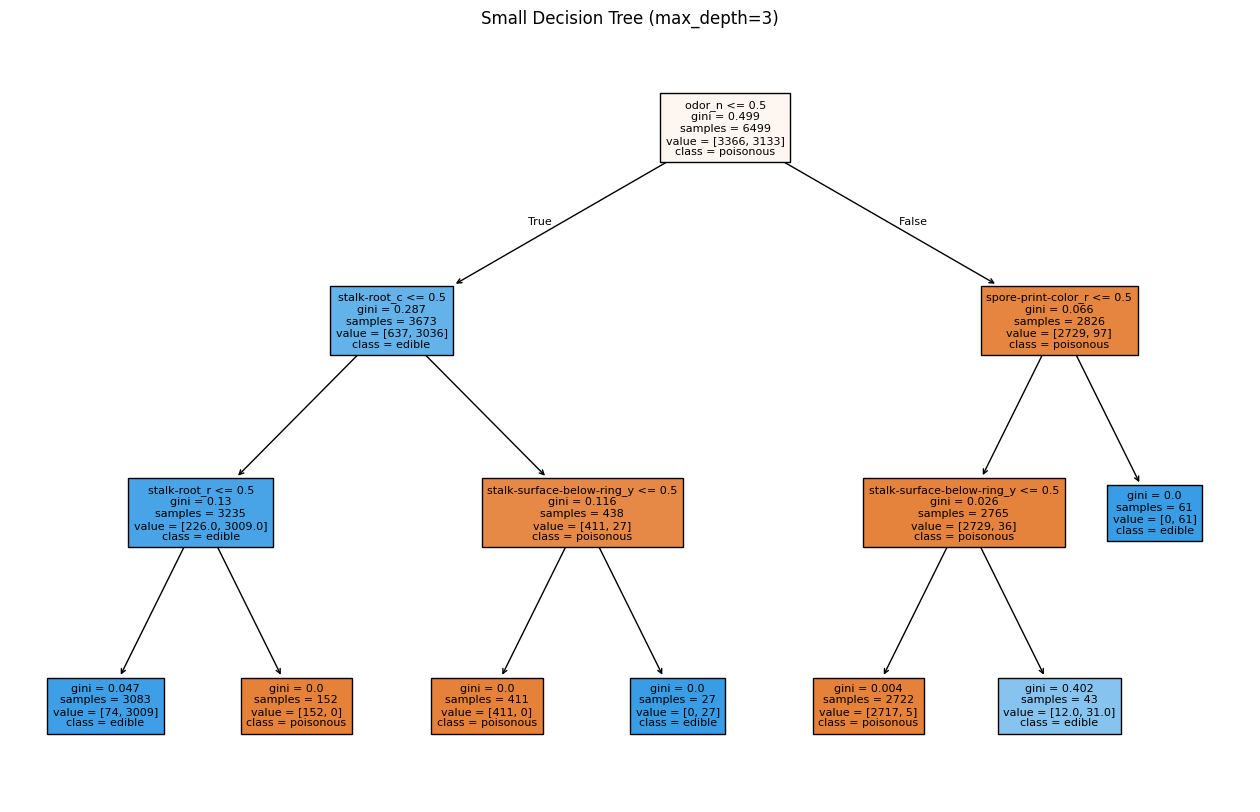

In [35]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Restrict max_depth to make it readable
dt_small = DecisionTreeClassifier(
    max_depth=3,
    criterion="gini",
    random_state=42
)
dt_small.fit(X_train, y_train)

plt.figure(figsize=(16, 10))
plot_tree(
    dt_small,
    max_depth=3,
    feature_names=ohe.get_feature_names_out(),
    class_names=["poisonous", "edible"],
    filled=True,
    fontsize=8
)
plt.title("Small Decision Tree (max_depth=3)")
plt.show()

In [36]:
# Feature importances from the gini tree (full depth)
dt_full_gini = DecisionTreeClassifier(random_state=42)
dt_full_gini.fit(X_train, y_train)

importances = dt_full_gini.feature_importances_
feature_names = ohe.get_feature_names_out()

# Sort by importance
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Top 10 most important features:")
print(importance_df.head(10))

Top 10 most important features:
                       feature  importance
22                      odor_n    0.617790
42                stalk-root_c    0.179322
44                stalk-root_r    0.085038
80         spore-print-color_r    0.035830
20                      odor_l    0.021383
65    stalk-color-below-ring_w    0.015614
50  stalk-surface-below-ring_y    0.013490
81         spore-print-color_u    0.010882
17                   bruises_t    0.010396
88                population_y    0.005331


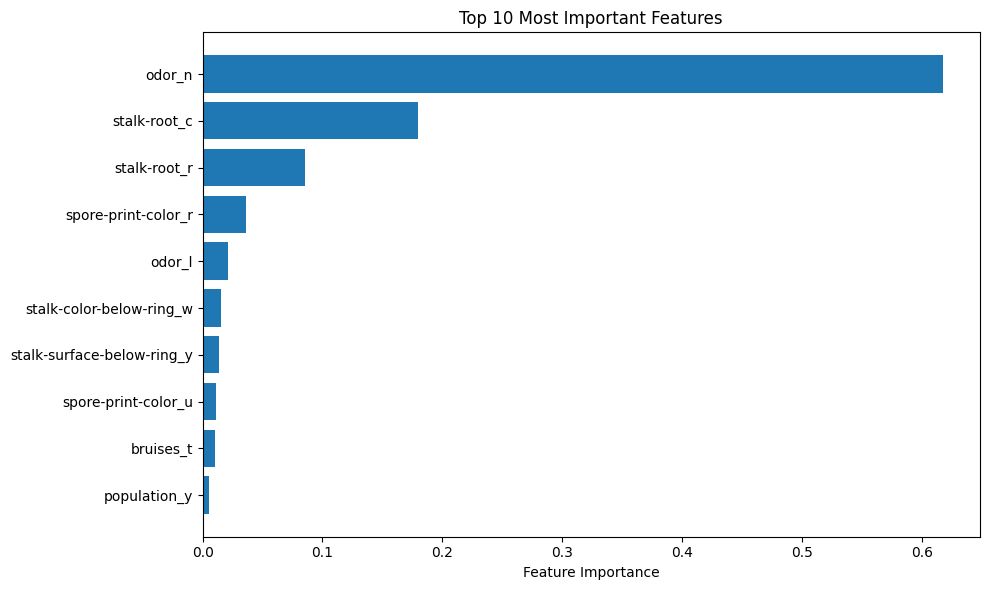

In [37]:
plt.figure(figsize=(10, 6))
top10 = importance_df.head(10)
plt.barh(top10["feature"], top10["importance"])
plt.xlabel("Feature Importance")
plt.title("Top 10 Most Important Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [38]:
# 1. Unpruned tree (no depth limit)
dt_unpruned = DecisionTreeClassifier(
    random_state=42,
    criterion="gini"
)
dt_unpruned.fit(X_train, y_train)
y_pred_unpruned = dt_unpruned.predict(X_test)
acc_unpruned = accuracy_score(y_test, y_pred_unpruned)

# 2. Pruned tree: limit depth
dt_pruned_depth = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    criterion="gini"
)
dt_pruned_depth.fit(X_train, y_train)
y_pred_depth = dt_pruned_depth.predict(X_test)
acc_depth = accuracy_score(y_test, y_pred_depth)

# 3. Pruned tree: min samples per split
dt_pruned_min = DecisionTreeClassifier(
    min_samples_split=50,
    random_state=42,
    criterion="gini"
)
dt_pruned_min.fit(X_train, y_train)
y_pred_min = dt_pruned_min.predict(X_test)
acc_min = accuracy_score(y_test, y_pred_min)

print("Unpruned tree accuracy:", acc_unpruned)
print("Pruned (max_depth=5) accuracy:", acc_depth)
print("Pruned (min_samples_split=50) accuracy:", acc_min)

print("\nTree sizes (number of nodes):")
print("Unpruned nodes:", dt_unpruned.tree_.node_count)
print("Pruned (max_depth=5) nodes:", dt_pruned_depth.tree_.node_count)
print("Pruned (min_samples_split=50) nodes:", dt_pruned_min.tree_.node_count)

Unpruned tree accuracy: 1.0
Pruned (max_depth=5) accuracy: 0.9963076923076923
Pruned (min_samples_split=50) accuracy: 0.9975384615384615

Tree sizes (number of nodes):
Unpruned nodes: 31
Pruned (max_depth=5) nodes: 23
Pruned (min_samples_split=50) nodes: 29
